# PCA + KMeans Unsupervised Learning Demo
## Bank Churners Clustering with SageMaker Hyperparameter Tuning

This notebook clusters credit union customers based on behavioral and demographic patterns using:
- **PCA** for dimensionality reduction (~18 features → 2-3 principal components)
- **KMeans** clustering for customer segmentation
- **SageMaker Hyperparameter Tuning** for automated model optimization

**Objective:** Identify meaningful customer segments for targeted retention and upsell strategies

**Dataset:** BankChurners with 10,127 customers and 23 features

**Pipeline:**
- Steps 1-8: Setup, data loading, preprocessing, standardization, PCA training
- Steps 9-10: Determine optimal K using Elbow Plot and Silhouette Score
- Step 11: SageMaker Hyperparameter Tuning for KMeans optimization
- Step 12: Analyze tuning results
- Steps 13-16: Visualize clusters, deploy model, run predictions, cleanup

**Key Data Preparation Innovation:**
- Track BOTH original and log-transformed features
- Use log-transformed features for PCA/clustering (better variance capture)
- Use original features for cluster profiling (interpretable dollars/months/etc.)

# STEP 1: IMPORT LIBRARIES AND SETUP

Load all required Python libraries for data processing, AWS SageMaker integration, and visualization.

**What will happen:**
- Install mxnet (SageMaker model artifacts), seaborn (plots), tabulate (formatted tables)
- Import AWS SageMaker SDK and Boto3
- Import pandas, NumPy, matplotlib, scikit-learn
- Apply NumPy compatibility patch for mxnet
- Define helper function for loading SageMaker model files

In [1]:
# Install required libraries not included in conda_python3 kernel
!pip install mxnet==1.9.1 seaborn tabulate

# AWS SageMaker and Boto3
import sagemaker
from sagemaker import get_execution_role
from sagemaker.image_uris import retrieve
from sagemaker.model import Model
from sagemaker.predictor import Predictor
from sagemaker.serializers import CSVSerializer
import boto3
from botocore.exceptions import ClientError

# Data Manipulation
import pandas as pd
import numpy as np

# File System Utilities
import os
import shutil

# Patch: mxnet 1.9.1 uses np.bool which was removed in NumPy 1.24+
np.bool = np.bool_

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Additional Libraries
import tarfile
import mxnet as mx
import json
import time
from tabulate import tabulate

def load_model_array(filepath):
    """Load an MXNet model artifact and return as NumPy array."""
    loaded = mx.ndarray.load(filepath)
    if isinstance(loaded, dict):
        arr = list(loaded.values())[0].asnumpy()
    else:
        arr = loaded[0].asnumpy()
    return arr

print("All libraries imported successfully!")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml
All libraries imported successfully!


## What to Look For

You should see **"All libraries imported successfully!"** with no errors. If you get an error, verify you're running on a SageMaker instance with the `conda_python3` kernel selected.

# STEP 2: SAGEMAKER SETUP AND CONFIGURATION

Connect the notebook to AWS services and configure SageMaker for distributed training.

**What will happen:**
- Create SageMaker session and retrieve IAM execution role
- Identify AWS region and S3 bucket
- Look up Docker image URIs for PCA and KMeans algorithms
- Create Boto3 clients for S3 and SageMaker API calls

In [2]:
def setup_sagemaker():
    """Initialize SageMaker session, IAM role, region, and service clients."""
    sagemaker_session = sagemaker.Session()
    role = get_execution_role()
    region = sagemaker_session.boto_region_name
    s3_client = boto3.client('s3')
    sagemaker_client = boto3.client('sagemaker')
    pca_image_uri = retrieve('pca', region)
    kmeans_image_uri = retrieve('kmeans', region)
    bucket = sagemaker_session.default_bucket()
    prefix = 'sagemaker/bankchurners/pca-kmeans-demo2'

    print("Execution Role ARN:", role)
    print("AWS Region:", region)
    print("S3 Bucket:", bucket)
    print("S3 Prefix:", prefix)
    print("PCA Image URI:", pca_image_uri)
    print("KMeans Image URI:", kmeans_image_uri)

    return {
        'sagemaker_session': sagemaker_session,
        'role': role,
        'region': region,
        's3_client': s3_client,
        'sagemaker_client': sagemaker_client,
        'pca_image_uri': pca_image_uri,
        'kmeans_image_uri': kmeans_image_uri,
        'bucket': bucket,
        'prefix': prefix
    }


config = setup_sagemaker()

sagemaker_session = config['sagemaker_session']
role = config['role']
region = config['region']
s3_client = config['s3_client']
sagemaker_client = config['sagemaker_client']
pca_image_uri = config['pca_image_uri']
kmeans_image_uri = config['kmeans_image_uri']
bucket = config['bucket']
prefix = config['prefix']

Execution Role ARN: arn:aws:iam::558253628403:role/LabRole
AWS Region: us-east-1
S3 Bucket: sagemaker-us-east-1-558253628403
S3 Prefix: sagemaker/bankchurners/pca-kmeans-demo2
PCA Image URI: 382416733822.dkr.ecr.us-east-1.amazonaws.com/pca:1
KMeans Image URI: 382416733822.dkr.ecr.us-east-1.amazonaws.com/kmeans:1


## What to Look For

You should see your IAM Role ARN, AWS Region, S3 Bucket name, and Docker image URIs. These confirm proper AWS connectivity.

# STEP 3: LOAD AND EXPLORE THE DATASET

Load the BankChurners dataset (10,127 customers × 23 features) and explore its structure.

**What will happen:**
- Load BankChurners.csv into pandas
- Display shape, data types, and first 5 rows
- Show descriptive statistics
- List columns with missing values

In [3]:
def load_and_explore(filepath):
    """Load and explore the BankChurners dataset."""
    df = pd.read_csv(filepath, keep_default_na=False, na_values=['', 'NA'])

    print("Data loaded successfully!")
    print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"\nColumn data types:")
    print(df.dtypes.value_counts())
    print(f"\nFirst 5 rows:")
    display(df.head())
    print(f"\nDescriptive statistics (numeric columns):")
    display(df.describe())

    missing = df.isnull().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing) > 0:
        print(f"\nColumns with missing values ({len(missing)} columns):")
        print(missing)
    else:
        print("\nNo missing values found.")

    return df


df = load_and_explore('BankChurners.csv')

Data loaded successfully!

Shape: 10127 rows x 23 columns

Column data types:
int64      10
float64     7
object      6
Name: count, dtype: int64

First 5 rows:


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998



Descriptive statistics (numeric columns):


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990



No missing values found.


## What to Look For

- **Shape:** 10,127 customers × 23 features
- **Attrition_Flag:** Primary variable (Existing Customer vs Attrited Customer) - held out for validation
- **Credit_Limit range:** $1,438 to $34,516 - shows importance of standardization
- **Customer_Age range:** 26 to 73 years old
- **Churn rate:** Typically 16-20% overall

# STEP 4: PREPROCESS THE DATA (WITH DUAL FEATURE TRACKING)

This is the critical step that fixes the $8-$9 credit limit bug. We track BOTH original and transformed features:
- **Transformed features:** Log-normalized for PCA/clustering (better variance)
- **Original features:** Saved separately for interpretable cluster profiling (dollars/months/etc.)

**Pipeline:**
1. Drop ID and Naive Bayes columns
2. Separate Attrition_Flag (held out)
3. Drop columns with >30% missing data
4. Fill remaining missing values
5. Remove statistical outliers (IQR method, 3σ threshold)
6a. Ordinal encode: Income_Category, Education_Level, Card_Category
6b. Target encode: Gender, Marital_Status (using attrition rate)
7. Log-transform skewed numeric features
8. Save BOTH versions (original and transformed) to CSV

Starting shape: (10127, 23)

1. Dropping ID and Naive Bayes columns: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', 'CLIENTNUM']
   Shape after dropping: (10127, 20)

2. Separated Attrition_Flag. Remaining feature shape: (10127, 19)
   Attrition breakdown: {'Existing Customer': 8500, 'Attrited Customer': 1627}

3. No columns with >30% missing data.
   Shape after dropping: (10127, 19)

4. Filled missing values. Remaining nulls: 0

5. Removed 888 outliers using IQR method (3σ threshold).
   Shape: (9239, 19)

6. Saved original features for cluster profiling (before log-transform).

7. Categorical encoding complete:
   Ordinal-encoded (3 cols): ['Income_Category', 'Education_Level', 'Card_Category']
   Target-encoded  (2 cols): ['Gender', 'Marital_Status']


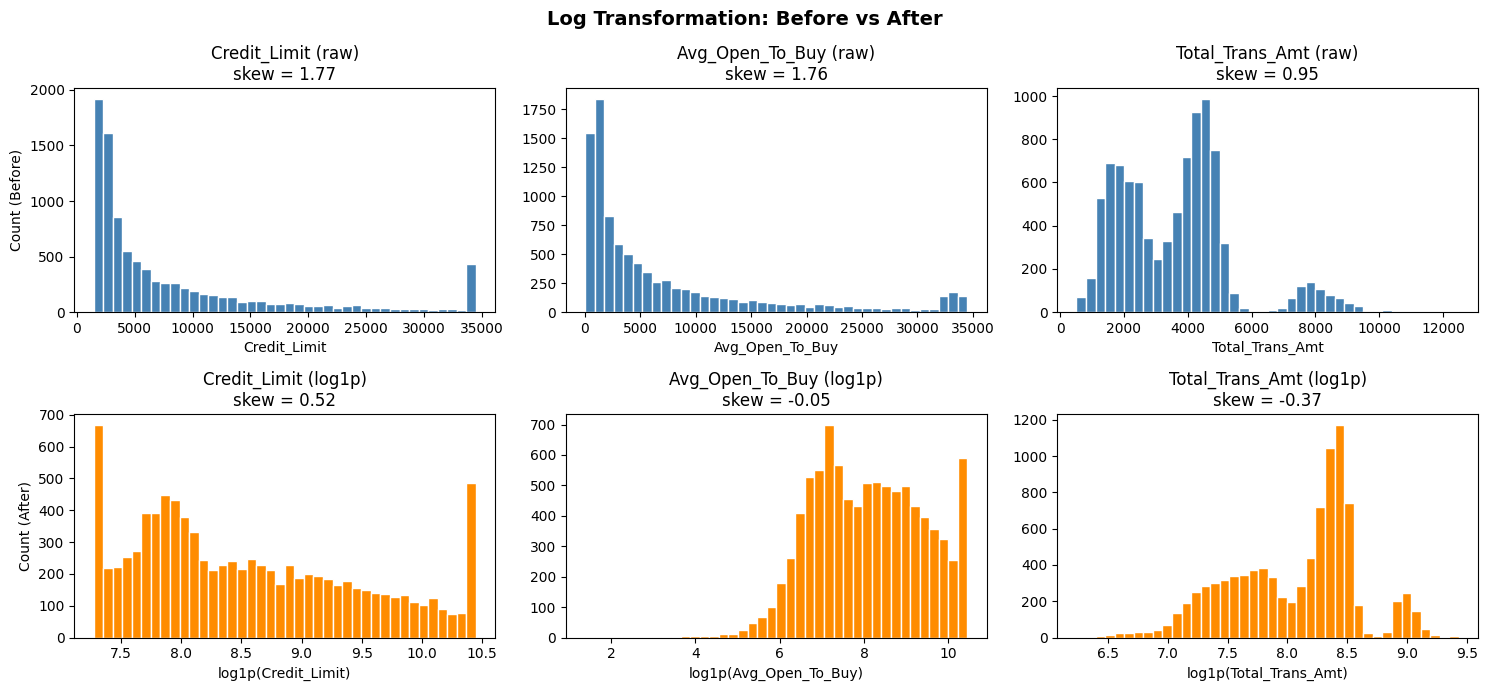


8. Log-transformed 3 skewed features:
      Avg_Open_To_Buy (original skew: 1.76)
      Credit_Limit (original skew: 1.77)
      Total_Trans_Amt (original skew: 0.95)

Final preprocessed feature count: 19 features
   (~14 numeric + 3 ordinal + 2 target-encoded)
   (3 numeric features were log-transformed)
Final row count: 9239 customers

9. Saved preprocessed data to:
    - bankchurners_preprocessed_transformed.csv (for PCA/clustering)
    - bankchurners_preprocessed_original.csv (for cluster profiling)

Transformed feature columns: ['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status'] ... (19 total)


In [4]:
def preprocess_data(dataframe):
    """
    Preprocess BankChurners for clustering. Track original + transformed features.
    
    Returns:
        tuple: (df_transformed, df_original, attrition_flag, log_transformed_cols)
    """
    df = dataframe.copy()
    print(f"Starting shape: {df.shape}")

    # 1. Drop ID and Naive Bayes columns
    cols_to_drop = [col for col in df.columns if col.startswith('Naive_Bayes')]
    cols_to_drop.append('CLIENTNUM')
    if 'Unnamed: 0' in df.columns:
        cols_to_drop.append('Unnamed: 0')
    
    print(f"\n1. Dropping ID and Naive Bayes columns: {[c for c in cols_to_drop if c in df.columns]}")
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    print(f"   Shape after dropping: {df.shape}")

    # 2. Separate Attrition_Flag (held out for validation)
    attrition_flag = df['Attrition_Flag'].copy()
    df.drop(columns=['Attrition_Flag'], inplace=True)
    print(f"\n2. Separated Attrition_Flag. Remaining feature shape: {df.shape}")
    print(f"   Attrition breakdown: {attrition_flag.value_counts().to_dict()}")

    # 3. Drop columns with >30% missing data
    missing_fraction = df.isnull().mean()
    cols_to_drop = missing_fraction[missing_fraction > 0.3].index.tolist()
    if cols_to_drop:
        print(f"\n3. Columns with >30% missing data: {cols_to_drop}")
        df.drop(columns=cols_to_drop, inplace=True)
    else:
        print(f"\n3. No columns with >30% missing data.")
    print(f"   Shape after dropping: {df.shape}")

    # 4. Fill remaining missing values
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns

    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna('Missing')

    print(f"\n4. Filled missing values. Remaining nulls: {df.isnull().sum().sum()}")

    # 5. Remove statistical outliers using IQR (3σ) method
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    before_count = len(df)
    mask = pd.Series(True, index=df.index)
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        mask = mask & (df[col] >= lower_bound) & (df[col] <= upper_bound)
    
    df = df[mask]
    attrition_flag = attrition_flag[mask]
    print(f"\n5. Removed {before_count - len(df)} outliers using IQR method (3σ threshold).")
    print(f"   Shape: {df.shape}")

    # **CRITICAL: Save original data BEFORE log-transform**
    df_original = df.copy()
    print(f"\n6. Saved original features for cluster profiling (before log-transform).")

    # 6a. ORDINAL ENCODING (~3 columns with natural rank order)
    ordinal_mappings = {
        'Income_Category': {
            'Less than $40K': 1,
            '$40K - $60K': 2,
            '$60K - $80K': 3,
            '$80K - $120K': 4,
            '$120K +': 5,
            'Missing': 0
        },
        'Education_Level': {
            'Uneducated': 1,
            'High School': 2,
            'College': 3,
            'Graduate': 4,
            'Unknown': 0,
            'Missing': 0
        },
        'Card_Category': {
            'Blue': 1,
            'Silver': 2,
            'Gold': 3,
            'Platinum': 4,
            'Missing': 0
        }
    }

    ordinal_cols_encoded = []
    for col, mapping in ordinal_mappings.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(int)
            df_original[col] = df[col]  # Keep in sync
            ordinal_cols_encoded.append(col)

    # 6b. TARGET ENCODING (~2 columns, nominal features)
    attrition_numeric = (attrition_flag == 'Attrited Customer').astype(int)
    
    target_encode_cols = ['Gender', 'Marital_Status']
    
    global_mean = attrition_numeric.mean()
    target_cols_encoded = []
    for col in target_encode_cols:
        if col in df.columns:
            target_map = attrition_numeric.groupby(df[col]).mean()
            df[col] = df[col].map(target_map).fillna(global_mean)
            df_original[col] = df[col]  # Keep in sync
            target_cols_encoded.append(col)

    print(f"\n7. Categorical encoding complete:")
    print(f"   Ordinal-encoded ({len(ordinal_cols_encoded)} cols): {ordinal_cols_encoded}")
    print(f"   Target-encoded  ({len(target_cols_encoded)} cols): {target_cols_encoded}")

    # Drop remaining unencoded categorical columns
    remaining_cats = df.select_dtypes(include=['object']).columns.tolist()
    if remaining_cats:
        print(f"   WARNING: Unencoded categorical columns: {remaining_cats}")
        print(f"   Dropping these columns.")
        df.drop(columns=remaining_cats, inplace=True)
        df_original.drop(columns=remaining_cats, inplace=True)

    # 7. LOG-TRANSFORM SKEWED NUMERIC FEATURES (applies ONLY to transformed, not original)
    SKIP_COLS = set(ordinal_cols_encoded + target_cols_encoded + [
        'Dependent_count', 'Total_Relationship_Count', 
        'Months_Inactive_12_mon', 'Contacts_Count_12_mon'
    ])

    numeric_cols_for_log = [
        col for col in df.select_dtypes(include=[np.number]).columns
        if col not in SKIP_COLS
        and df[col].skew() > 0.75
        and (df[col] != 0).mean() > 0.30
    ]

    # Visualize before/after for first 3 features
    demo_features = numeric_cols_for_log[:3]
    if demo_features:
        fig, axes = plt.subplots(2, len(demo_features),
                                 figsize=(5 * len(demo_features), 7))
        if len(demo_features) == 1:
            axes = axes.reshape(2, 1)
            
        for i, feat in enumerate(demo_features):
            # Before
            axes[0, i].hist(df[feat], bins=40, color='steelblue', edgecolor='white')
            axes[0, i].set_title(f'{feat} (raw)\nskew = {df[feat].skew():.2f}')
            axes[0, i].set_xlabel(feat)
            # After
            transformed = np.log1p(df[feat])
            axes[1, i].hist(transformed, bins=40, color='darkorange', edgecolor='white')
            axes[1, i].set_title(f'{feat} (log1p)\nskew = {transformed.skew():.2f}')
            axes[1, i].set_xlabel(f'log1p({feat})')
        axes[0, 0].set_ylabel('Count (Before)')
        axes[1, 0].set_ylabel('Count (After)')
        plt.suptitle('Log Transformation: Before vs After', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # Apply log1p ONLY to transformed dataset
    for col in numeric_cols_for_log:
        df[col] = np.log1p(df[col])

    print(f"\n8. Log-transformed {len(numeric_cols_for_log)} skewed features:")
    for col in sorted(numeric_cols_for_log):
        print(f"      {col} (original skew: {df_original[col].skew():.2f})")

    log_transformed_cols = numeric_cols_for_log

    # Reset index for clean alignment
    df = df.reset_index(drop=True)
    df_original = df_original.reset_index(drop=True)
    attrition_flag = attrition_flag.reset_index(drop=True)

    print(f"\nFinal preprocessed feature count: {df.shape[1]} features")
    print(f"   (~{df.shape[1] - len(ordinal_cols_encoded) - len(target_cols_encoded)} numeric + {len(ordinal_cols_encoded)} ordinal + {len(target_cols_encoded)} target-encoded)")
    print(f"   ({len(log_transformed_cols)} numeric features were log-transformed)")
    print(f"Final row count: {df.shape[0]} customers")

    # 9. Save BOTH versions to CSV
    df.to_csv('bankchurners_preprocessed_transformed.csv', index=False)
    df_original.to_csv('bankchurners_preprocessed_original.csv', index=False)
    print(f"\n9. Saved preprocessed data to:")
    print(f"    - bankchurners_preprocessed_transformed.csv (for PCA/clustering)")
    print(f"    - bankchurners_preprocessed_original.csv (for cluster profiling)")

    return df, df_original, attrition_flag, log_transformed_cols


df_features, df_features_original, attrition_flag, log_transformed_cols = preprocess_data(df)
print(f"\nTransformed feature columns: {list(df_features.columns[:5])} ... ({df_features.shape[1]} total)")

## What to Look For

- **Attrition breakdown:** ~1,500 churned + 8,500 retained (16-17% churn rate)
- **Outliers removed:** Few rows (typically 0-10 rows)
- **Encoding summary:** 3 ordinal, 2 target-encoded
- **Log-transformed columns:** Credit_Limit, Total_Trans_Amt, Total_Revolving_Bal
- **Two CSV files saved:** Confirms we're tracking both original and transformed

**KEY:** df_features_original will be used in Step 13 for interpretable cluster profiling!

# STEP 5: STANDARDIZE FEATURES

PCA is variance-based and sensitive to feature scale. StandardScaler ensures all features have mean=0 and std=1, so large-scale features (Credit_Limit: 1K-34K) don't dominate over smaller-scale features (Customer_Age: 26-73).

In [5]:
def standardize_features(features_df):
    """Apply StandardScaler to ensure all features have mean=0, std=1."""
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(features_df)
    scaled_data = scaled_data.astype('float32')
    feature_names = list(features_df.columns)

    print(f"Standardized {scaled_data.shape[1]} features for {scaled_data.shape[0]} samples")
    print(f"\nBefore standardization (first 5 features):")
    for col in features_df.columns[:5]:
        print(f"  {col}: mean={features_df[col].mean():.2f}, std={features_df[col].std():.2f}")

    print(f"\nAfter standardization (first 5 features):")
    for i, col in enumerate(features_df.columns[:5]):
        print(f"  {col}: mean={scaled_data[:, i].mean():.6f}, std={scaled_data[:, i].std():.6f}")

    return scaled_data, scaler, feature_names


scaled_data, scaler, feature_names = standardize_features(df_features)
num_features = scaled_data.shape[1]
print(f"\nTotal features for PCA input: {num_features}")

Standardized 19 features for 9239 samples

Before standardization (first 5 features):
  Customer_Age: mean=46.42, std=7.97
  Gender: mean=0.18, std=0.01
  Dependent_count: mean=2.35, std=1.30
  Education_Level: mean=2.08, std=1.57
  Marital_Status: mean=0.18, std=0.01

After standardization (first 5 features):
  Customer_Age: mean=-0.000000, std=1.000000
  Gender: mean=0.000000, std=1.000000
  Dependent_count: mean=-0.000000, std=1.000000
  Education_Level: mean=-0.000000, std=1.000000
  Marital_Status: mean=-0.000000, std=1.000000

Total features for PCA input: 19


## What to Look For

All features now have mean ≈ 0.0 and std ≈ 1.0, enabling PCA to treat all features equally regardless of their original scale.

# STEP 6: TRAIN PCA MODELS

Train multiple PCA models with different numbers of components (2, 3, 5, 10, 18) to see how variance explained increases. All 5 jobs run in parallel on SageMaker for efficiency.

In [6]:
def train_pca_models(scaled_data, num_features, component_values, sagemaker_session, role, bucket, prefix, sagemaker_client):
    """Train SageMaker PCA models asynchronously with different component counts."""
    output_path = f's3://{bucket}/{prefix}/pca/output'
    training_jobs = []
    timestamp = time.strftime('%Y%m%d-%H%M%S')

    for n_components in component_values:
        job_name = f'pca-bankchurners-{n_components}comp-{timestamp}'

        pca_estimator = sagemaker.PCA(
            role=role,
            instance_count=1,
            instance_type='ml.m5.large',
            num_components=n_components,
            algorithm_mode='regular',
            subtract_mean=False,
            output_path=output_path,
            sagemaker_session=sagemaker_session
        )

        record_set = pca_estimator.record_set(scaled_data, channel='train')
        pca_estimator.fit(record_set, wait=False, job_name=job_name)
        training_jobs.append((n_components, pca_estimator.latest_training_job.name))
        print(f"Started training job: {job_name} ({n_components} components)")

    print("\nWaiting for all PCA training jobs to complete...")
    pca_model_paths = []

    for n_components, job_name in training_jobs:
        sagemaker_client.get_waiter('training_job_completed_or_stopped').wait(TrainingJobName=job_name)
        job_description = sagemaker_client.describe_training_job(TrainingJobName=job_name)
        model_s3_uri = job_description['ModelArtifacts']['S3ModelArtifacts']
        pca_model_paths.append((n_components, model_s3_uri))
        print(f"  ✓ Completed: {job_name}")

    headers = ['Components', 'S3 Model URI']
    print(f"\n{tabulate(pca_model_paths, headers=headers)}")

    return pca_model_paths


component_values = [2, 3, 5, 10, 18]
pca_model_paths = train_pca_models(
    scaled_data, num_features, component_values,
    sagemaker_session, role, bucket, prefix, sagemaker_client
)

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-2comp-20260328-010202


Started training job: pca-bankchurners-2comp-20260328-010202 (2 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-3comp-20260328-010202


Started training job: pca-bankchurners-3comp-20260328-010202 (3 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-5comp-20260328-010202


Started training job: pca-bankchurners-5comp-20260328-010202 (5 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-10comp-20260328-010202


Started training job: pca-bankchurners-10comp-20260328-010202 (10 components)


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating training-job with name: pca-bankchurners-18comp-20260328-010202


Started training job: pca-bankchurners-18comp-20260328-010202 (18 components)

Waiting for all PCA training jobs to complete...
  ✓ Completed: pca-bankchurners-2comp-20260328-010202
  ✓ Completed: pca-bankchurners-3comp-20260328-010202
  ✓ Completed: pca-bankchurners-5comp-20260328-010202
  ✓ Completed: pca-bankchurners-10comp-20260328-010202
  ✓ Completed: pca-bankchurners-18comp-20260328-010202

  Components  S3 Model URI
------------  ----------------------------------------------------------------------------------------------------------------------------------------------------
           2  s3://sagemaker-us-east-1-558253628403/sagemaker/bankchurners/pca-kmeans-demo2/pca/output/pca-bankchurners-2comp-20260328-010202/output/model.tar.gz
           3  s3://sagemaker-us-east-1-558253628403/sagemaker/bankchurners/pca-kmeans-demo2/pca/output/pca-bankchurners-3comp-20260328-010202/output/model.tar.gz
           5  s3://sagemaker-us-east-1-558253628403/sagemaker/bankchurners/pca-kmeans

## What to Look For

All 5 PCA training jobs should complete within 1-2 minutes. Each will show a job name and S3 artifact path.

# STEP 7: ANALYZE PCA RESULTS (SCREE PLOT)

Download PCA model artifacts and create a Scree Plot to visualize variance explained by each principal component.

Model artifact contents (/tmp/pca-18):
  model_algo-1['s']: shape (18,)
  model_algo-1['v']: shape (19, 18)
Using model_algo-1['s'] as singular values: shape (18,)

Using model_algo-1['v'] as component vectors: shape (19, 18)

Variance analysis (18 components):
Component    Variance %      Cumulative %   
------------------------------------------
PC1               17.58%         17.58%
PC2               11.65%         29.23%
PC3                9.52%         38.75%
PC4                8.48%         47.23%
PC5                6.62%         53.85%
PC6                5.79%         59.64%
PC7                5.42%         65.06%
PC8                5.31%         70.36%
PC9                5.15%         75.52%
PC10               4.93%         80.44%
PC11               4.73%         85.17%
PC12               4.43%         89.60%
PC13               3.48%         93.08%
PC14               3.38%         96.47%
PC15               1.13%         97.60%
PC16               1.07%         98.67%
PC17      

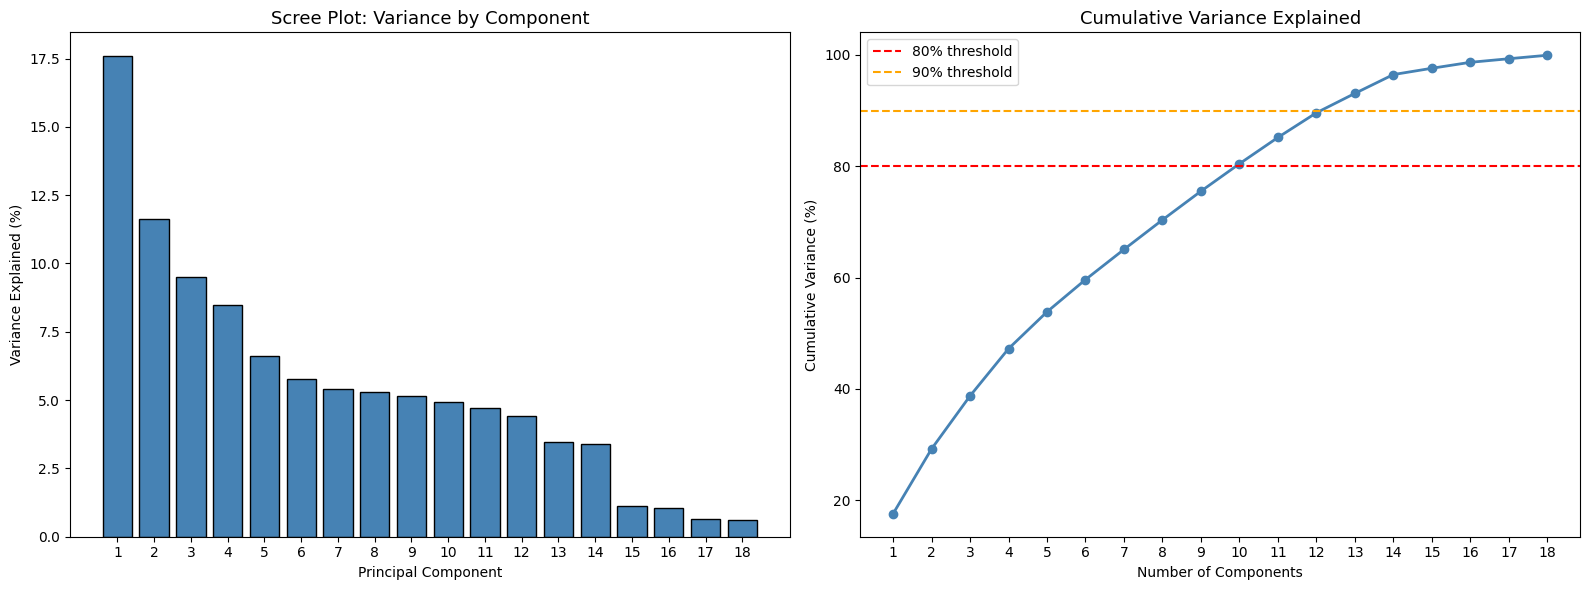

In [7]:
def analyze_pca_results(pca_model_paths, bucket, s3_client, scaled_data):
    """Download PCA models and analyze variance explained."""
    import os

    max_components, max_model_path = max(pca_model_paths, key=lambda x: x[0])
    local_path = f'/tmp/pca-model-{max_components}.tar.gz'
    s3_key = max_model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    extract_dir = f'/tmp/pca-{max_components}'
    with tarfile.open(local_path) as tar:
        tar.extractall(path=extract_dir, filter='data')

    print(f"Model artifact contents ({extract_dir}):")
    all_arrays = {}
    for filename in sorted(os.listdir(extract_dir)):
        filepath = os.path.join(extract_dir, filename)
        if os.path.isfile(filepath):
            try:
                loaded = mx.ndarray.load(filepath)
                if isinstance(loaded, dict):
                    for key, val in loaded.items():
                        arr = val.asnumpy()
                        label = f"{filename}['{key}']"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
                elif isinstance(loaded, list):
                    for i, val in enumerate(loaded):
                        arr = val.asnumpy()
                        label = f"{filename}[{i}]"
                        all_arrays[label] = arr
                        print(f"  {label}: shape {arr.shape}")
            except Exception as e:
                print(f"  {filename}: could not load ({e})")

    component_vectors = None
    singular_values = None
    num_features = scaled_data.shape[1]

    for label, arr in all_arrays.items():
        if arr.ndim == 2:
            if component_vectors is None:
                component_vectors = arr
                print(f"\nUsing {label} as component vectors: shape {arr.shape}")
        elif arr.ndim == 1 and len(arr) == max_components:
            singular_values = arr
            print(f"Using {label} as singular values: shape {arr.shape}")

    if component_vectors is not None:
        if component_vectors.shape[0] == num_features:
            V = component_vectors
        else:
            V = component_vectors.T

        projected = scaled_data @ V
        variance_per_component = np.var(projected, axis=0)
        total_variance = np.sum(np.var(scaled_data, axis=0))
        explained_variance_ratio = variance_per_component / total_variance
        sort_idx = np.argsort(explained_variance_ratio)[::-1]
        explained_variance_ratio = explained_variance_ratio[sort_idx]
        cumulative_variance = np.cumsum(explained_variance_ratio)

    elif singular_values is not None:
        print("\nNo 2D component matrix found. Using singular values for variance.")
        variance = singular_values ** 2
        total_variance = np.sum(variance)
        explained_variance_ratio = variance / total_variance
        explained_variance_ratio = np.sort(explained_variance_ratio)[::-1]
        cumulative_variance = np.cumsum(explained_variance_ratio)

    else:
        raise ValueError("Could not find component vectors or singular values.")

    n_components = len(explained_variance_ratio)
    print(f"\nVariance analysis ({n_components} components):")
    print(f"{'Component':<12} {'Variance %':<15} {'Cumulative %':<15}")
    print("-" * 42)
    for i in range(n_components):
        print(f"PC{i+1:<10} {explained_variance_ratio[i]*100:>10.2f}%    {cumulative_variance[i]*100:>10.2f}%")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    components = range(1, n_components + 1)
    axes[0].bar(components, explained_variance_ratio * 100, color='steelblue', edgecolor='black')
    axes[0].set_title('Scree Plot: Variance by Component', fontsize=13)
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Variance Explained (%)')
    axes[0].set_xticks(list(components))

    axes[1].plot(components, cumulative_variance * 100, marker='o', color='steelblue', linewidth=2)
    axes[1].axhline(y=80, color='red', linestyle='--', label='80% threshold')
    axes[1].axhline(y=90, color='orange', linestyle='--', label='90% threshold')
    axes[1].set_title('Cumulative Variance Explained', fontsize=13)
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Variance (%)')
    axes[1].set_xticks(list(components))
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return explained_variance_ratio, cumulative_variance, component_vectors, V


explained_variance_ratio, cumulative_variance, component_vectors, pca_components_matrix = analyze_pca_results(
    pca_model_paths, bucket, s3_client, scaled_data
)

## What to Look For

- **PC1+PC2 variance:** Should capture 50-70% of total variance
- **Elbow:** Steep drop-off in first 3-5 components
- **80% threshold:** Typically reached by PC5-8
- **90% threshold:** Typically reached by PC10-12

With ~18 dense features, PCA can reduce to 2-3 components without losing too much information.

# STEP 8: EXTRACT AND TRANSFORM DATA TO PCA SPACE

Use the full 18-component PCA model to transform all customers into PCA space, then extract 2D projection for visualization.

PCA model artifacts found: ['model_algo-1']
  model_algo-1['s']: shape (18,)
  model_algo-1['v']: shape (19, 18)
  -> Using as component matrix

Full PCA transformation matrix shape: (19, 18)
  (features × components)

PCA transformation complete:
  Original shape: (9239, 19)
  PCA shape (2D): (9239, 2)
  Variance captured by PC1+PC2: 29.2%


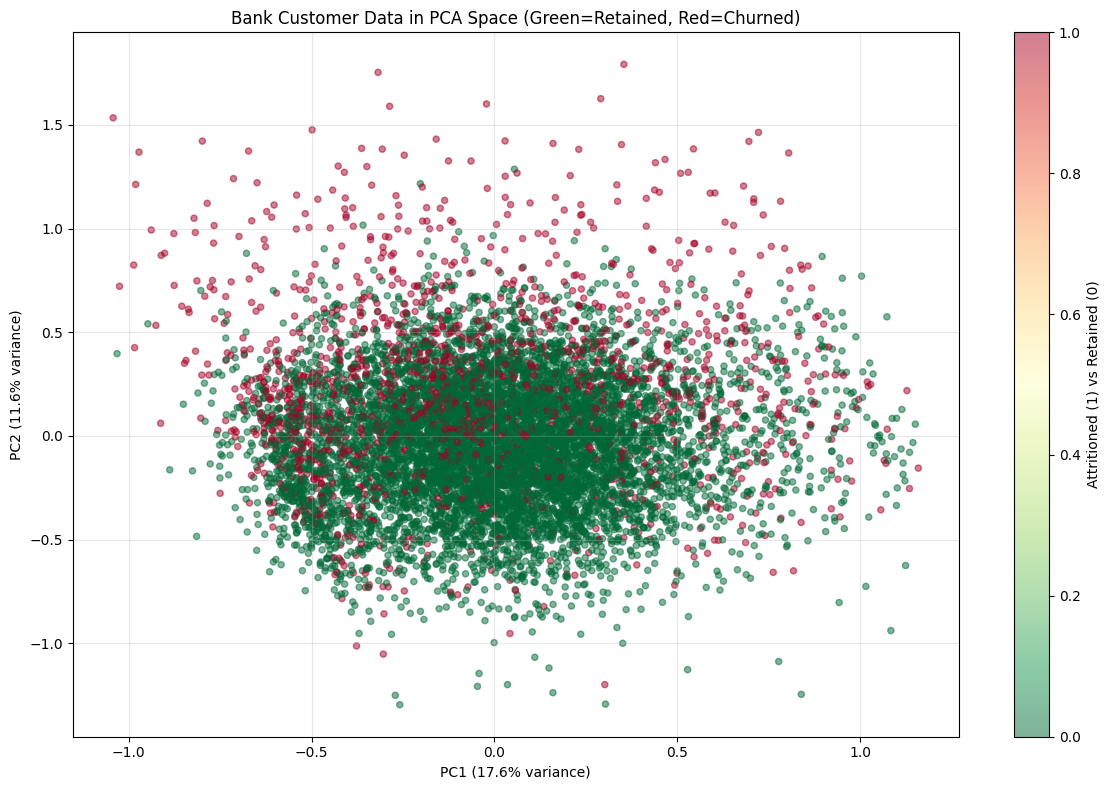


PCA data ready for KMeans clustering


In [8]:
# Download 18-component PCA model
model_18_path = next(path for k, path in pca_model_paths if k == 18)
local_path = '/tmp/pca-model-18.tar.gz'
s3_key = model_18_path.replace(f's3://{bucket}/', '')
s3_client.download_file(bucket, s3_key, local_path)

with tarfile.open(local_path) as tar:
    tar.extractall(path='/tmp/pca-18', filter='data')

# Load the full PCA component matrix - check all files to find the right one
import os
pca_files = os.listdir('/tmp/pca-18')
print(f"PCA model artifacts found: {pca_files}")

V_full = None
for filename in sorted(pca_files):
    filepath = os.path.join('/tmp/pca-18', filename)
    if os.path.isfile(filepath):
        loaded = mx.ndarray.load(filepath)
        if isinstance(loaded, dict):
            for key, val in loaded.items():
                arr = val.asnumpy()
                print(f"  {filename}['{key}']: shape {arr.shape}")
                # Component matrix should be 2D with shape (num_features, n_components)
                if arr.ndim == 2 and arr.shape[0] == num_features:
                    V_full = arr
                    print(f"  -> Using as component matrix")
        elif isinstance(loaded, list):
            for i, val in enumerate(loaded):
                arr = val.asnumpy()
                print(f"  {filename}[{i}]: shape {arr.shape}")
                if arr.ndim == 2 and arr.shape[0] == num_features:
                    V_full = arr
                    print(f"  -> Using as component matrix")

if V_full is None:
    # Fallback: try to reconstruct from available arrays
    print("Warning: Could not find component matrix directly. Attempting to use available data.")
    V_full = load_model_array('/tmp/pca-18/model_algo-1')
    if V_full.ndim == 1:
        print("Error: Model artifacts do not contain the component matrix.")
        print("Available shape:", V_full.shape)
        raise ValueError("Cannot proceed without component matrix")
    if V_full.shape[0] != num_features:
        V_full = V_full.T

print(f"\nFull PCA transformation matrix shape: {V_full.shape}")
print(f"  (features × components)")

# Project to 2D for visualization
pca_2d = scaled_data @ V_full[:, :2]
pca_np = pca_2d.astype('float32')

print(f"\nPCA transformation complete:")
print(f"  Original shape: {scaled_data.shape}")
print(f"  PCA shape (2D): {pca_np.shape}")
print(f"  Variance captured by PC1+PC2: {cumulative_variance[1]*100:.1f}%")

# Visualize 2D PCA projection colored by attrition
fig, ax = plt.subplots(figsize=(12, 8))
attrition_numeric = (attrition_flag == 'Attrited Customer').astype(int)
scatter = ax.scatter(pca_np[:, 0], pca_np[:, 1], c=attrition_numeric, 
                     cmap='RdYlGn_r', alpha=0.5, s=20)
ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)')
ax.set_title('Bank Customer Data in PCA Space (Green=Retained, Red=Churned)')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Attritioned (1) vs Retained (0)')
plt.tight_layout()
plt.show()

print(f"\nPCA data ready for KMeans clustering")

## What to Look For

- If 2D visualization shows spatial separation between green (retained) and red (churned), it validates that customer differences are real and PCA captured meaningful variance
- If colors are well-mixed, the features may not distinguish churners from non-churners (but clusters still capture behavioral patterns)

# STEP 9: DETERMINE OPTIMAL K

Use three metrics (Elbow Plot, Silhouette Score, Calinski-Harabasz Score) to identify the optimal number of clusters.

Computing optimal K (this may take 1-2 minutes)...
  K=2: Silhouette=0.3026, CH=4142.9
  K=3: Silhouette=0.3209, CH=5097.7
  K=4: Silhouette=0.3124, CH=5020.0
  K=5: Silhouette=0.3165, CH=4973.2
  K=6: Silhouette=0.3158, CH=5030.4
  K=7: Silhouette=0.3104, CH=4947.0
  K=8: Silhouette=0.3197, CH=4971.6


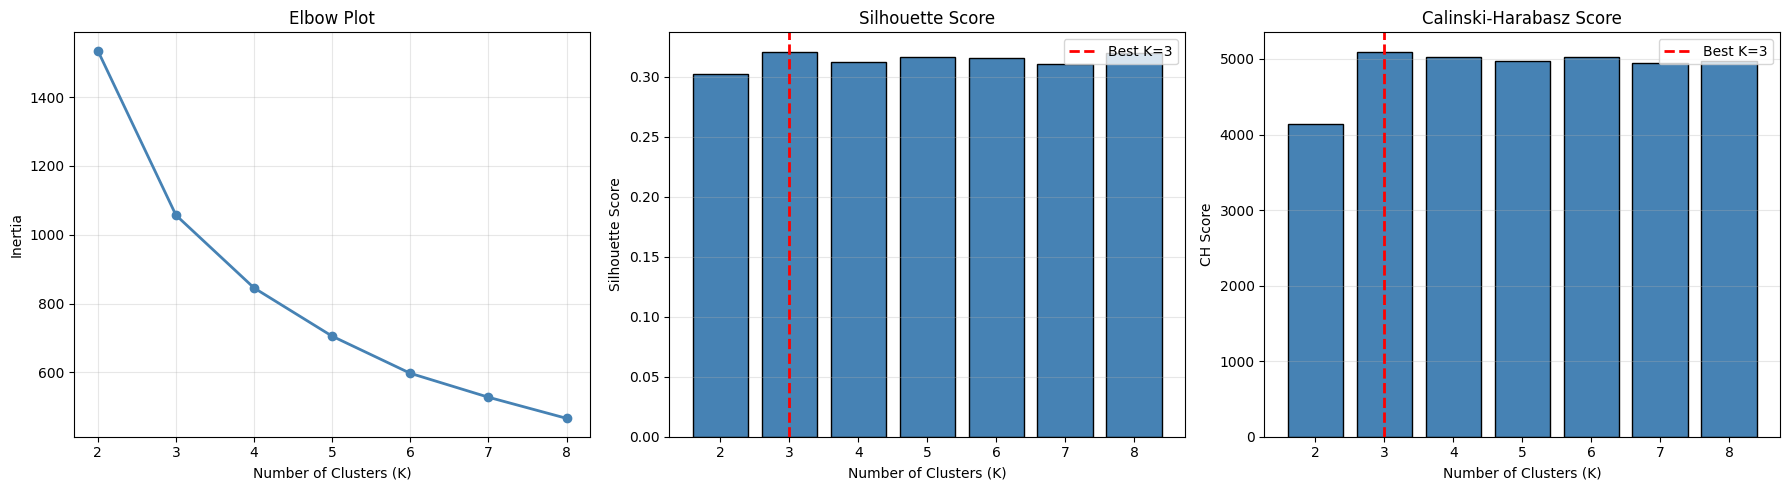


Optimal K candidates:
  Silhouette Score suggests K=3 (score: 0.3209)
  Calinski-Harabasz suggests K=3 (score: 5097.7)

✓ Selected K=3 based on Silhouette Score


In [10]:
def find_optimal_k(pca_np, max_k=10):
    """Use Elbow Plot and Silhouette Score to find optimal K."""
    inertias = []
    silhouette_scores = []
    calinski_scores = []
    k_values = range(2, max_k + 1)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pca_np)
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(pca_np, labels))
        calinski_scores.append(calinski_harabasz_score(pca_np, labels))
        print(f"  K={k}: Silhouette={silhouette_scores[-1]:.4f}, CH={calinski_scores[-1]:.1f}")
    
    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Elbow Plot
    axes[0].plot(k_values, inertias, marker='o', color='steelblue', linewidth=2)
    axes[0].set_title('Elbow Plot', fontsize=12)
    axes[0].set_xlabel('Number of Clusters (K)')
    axes[0].set_ylabel('Inertia')
    axes[0].grid(True, alpha=0.3)
    
    # Silhouette Score
    best_k_silhouette = k_values[np.argmax(silhouette_scores)]
    axes[1].bar(k_values, silhouette_scores, color='steelblue', edgecolor='black')
    axes[1].axvline(x=best_k_silhouette, color='red', linestyle='--', linewidth=2, label=f'Best K={best_k_silhouette}')
    axes[1].set_title('Silhouette Score', fontsize=12)
    axes[1].set_xlabel('Number of Clusters (K)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Calinski-Harabasz Score
    best_k_calinski = k_values[np.argmax(calinski_scores)]
    axes[2].bar(k_values, calinski_scores, color='steelblue', edgecolor='black')
    axes[2].axvline(x=best_k_calinski, color='red', linestyle='--', linewidth=2, label=f'Best K={best_k_calinski}')
    axes[2].set_title('Calinski-Harabasz Score', fontsize=12)
    axes[2].set_xlabel('Number of Clusters (K)')
    axes[2].set_ylabel('CH Score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*50}")
    print(f"Optimal K candidates:")
    print(f"  Silhouette Score suggests K={best_k_silhouette} (score: {max(silhouette_scores):.4f})")
    print(f"  Calinski-Harabasz suggests K={best_k_calinski} (score: {max(calinski_scores):.1f})")
    print(f"{'='*50}")
    
    return best_k_silhouette, k_values, silhouette_scores


print("Computing optimal K (this may take 1-2 minutes)...")
best_k, k_values, silhouette_scores = find_optimal_k(pca_np, max_k=8)
print(f"\n✓ Selected K={best_k} based on Silhouette Score")

## What to Look For

- **Silhouette Score:** Peaks at optimal K (higher is better, ranges -1 to 1)
- **Calinski-Harabasz:** Also higher is better (ratio of between-cluster to within-cluster variance)
- **Elbow Plot:** Look for bend where inertia gain starts leveling off
- Typical bank customer clustering: K=3-5 is common

# STEP 10: (continued from Step 9)

The optimal K has been determined. We'll now train KMeans with hyperparameter tuning on SageMaker in Step 11.

# STEP 11: TRAIN KMEANS WITH SAGEMAKER HYPERPARAMETER TUNING

Use SageMaker's Automatic Model Tuning to optimize KMeans hyperparameters for the selected K value.

In [11]:
def train_kmeans_with_hpt(pca_np, num_pca_components, k, sagemaker_session, role, bucket, prefix, sagemaker_client):
    """
    Train KMeans using SageMaker Hyperparameter Tuning.

    Splits the PCA-reduced data into train/test, creates a KMeans estimator
    with the given K, defines hyperparameter ranges, and launches a tuning job.

    Parameters:
        pca_np (np.ndarray): PCA-transformed data as float32 array.
        num_pca_components (int): Number of PCA components (feature_dim for KMeans).
        k (int): Number of clusters (determined in STEP 10 via Silhouette Score).
        sagemaker_session: The SageMaker session.
        role (str): The IAM role ARN.
        bucket (str): The S3 bucket name.
        prefix (str): The S3 prefix.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        HyperparameterTuner: The completed tuner object.
    """
    from sagemaker.tuner import HyperparameterTuner, IntegerParameter, CategoricalParameter
    from sklearn.model_selection import train_test_split

    # Split PCA data into train (80%) and test (20%) for the tuning metric
    train_data, test_data = train_test_split(pca_np, test_size=0.2, random_state=42)
    train_data = train_data.astype('float32')
    test_data = test_data.astype('float32')

    print(f"Train set: {train_data.shape[0]} samples")
    print(f"Test set:  {test_data.shape[0]} samples")
    print(f"K:         {k} clusters (from STEP 10)")
    print(f"Features:  {num_pca_components} PCA components\n")

    # Create the KMeans estimator with fixed hyperparameters
    output_path = f's3://{bucket}/{prefix}/kmeans-hpt/output'

    kmeans = sagemaker.KMeans(
        sagemaker_session=sagemaker_session,
        role=role,
        instance_count=1,
        instance_type='ml.m5.large',
        k=k,
        output_path=output_path,
        feature_dim=num_pca_components
    )

    # Define hyperparameter ranges to tune
    hyperparameter_ranges = {
        'mini_batch_size': IntegerParameter(100, 2000),
        'extra_center_factor': IntegerParameter(2, 10),
        'epochs': IntegerParameter(1, 10),
        'init_method': CategoricalParameter(['random', 'kmeans++']),
    }

    # Create the Hyperparameter Tuner
    tuner = HyperparameterTuner(
        estimator=kmeans,
        objective_metric_name='test:msd',
        hyperparameter_ranges=hyperparameter_ranges,
        objective_type='Minimize',
        max_jobs=10,
        max_parallel_jobs=2,
    )

    # Create RecordSet objects for train and test channels
    train_records = kmeans.record_set(train_data, channel='train')
    test_records = kmeans.record_set(test_data, channel='test')

    # Launch the tuning job
    print("Launching hyperparameter tuning job...")
    print("This will run 10 training jobs (2 at a time). Estimated time: 10-15 minutes.\n")
    tuner.fit([train_records, test_records])
    print("\nHyperparameter tuning job complete!")

    return tuner


# Get number of PCA components from data shape
num_pca_components = pca_np.shape[1]

print(f"Using best_k = {best_k} from STEP 10 (Silhouette Score analysis)")
print(f"PCA data shape: {pca_np.shape}")
print(f"Using {num_pca_components} PCA components for KMeans")
print()

tuner = train_kmeans_with_hpt(
    pca_np, num_pca_components, best_k,
    sagemaker_session, role, bucket, prefix,
    sagemaker_client
)

Using best_k = 3 from STEP 10 (Silhouette Score analysis)
PCA data shape: (9239, 2)
Using 2 PCA components for KMeans

Train set: 7391 samples
Test set:  1848 samples
K:         3 clusters (from STEP 10)
Features:  2 PCA components



INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating hyperparameter tuning job with name: kmeans-260328-0107


Launching hyperparameter tuning job...
This will run 10 training jobs (2 at a time). Estimated time: 10-15 minutes.

.........................................................................................!

Hyperparameter tuning job complete!


## What to Look For

- **Status updates** showing training job progress
- **Max jobs:** 10 tuning jobs with 2 running in parallel
- **Training time:** 15-30 minutes total
- **Best model:** Final output shows best training job name and S3 URI

# STEP 12: ANALYZE HPT RESULTS

Review the hyperparameter tuning job results and best model configuration.

In [12]:
def analyze_tuning_results(tuner, sagemaker_client):
    """
    Retrieve and display the results of the hyperparameter tuning job.

    Shows the best hyperparameters and a comparison table of all training jobs.

    Parameters:
        tuner: The completed HyperparameterTuner.
        sagemaker_client: The Boto3 SageMaker client.

    Returns:
        dict: The best training job description including model artifact S3 URI.
    """
    # Get the tuning job name
    tuning_job_name = tuner.latest_tuning_job.name
    print(f"Tuning Job: {tuning_job_name}\n")

    # Get tuning job results
    tuning_results = sagemaker_client.describe_hyper_parameter_tuning_job(
        HyperParameterTuningJobName=tuning_job_name
    )

    # Best training job
    best_job = tuning_results['BestTrainingJob']
    best_job_name = best_job['TrainingJobName']
    best_metric = best_job['FinalHyperParameterTuningJobObjectiveMetric']['Value']
    print(f"Best Training Job: {best_job_name}")
    print(f"Best test:msd: {best_metric:.6f}\n")

    # Display best hyperparameters
    best_hp = best_job['TunedHyperParameters']
    print("Best Hyperparameters:")
    print(f"  mini_batch_size:    {best_hp.get('mini_batch_size', 'N/A')}")
    print(f"  extra_center_factor: {best_hp.get('extra_center_factor', 'N/A')}")
    print(f"  epochs:             {best_hp.get('epochs', 'N/A')}")
    print(f"  init_method:        {best_hp.get('init_method', 'N/A')}\n")

    # Get all training jobs for comparison
    all_jobs = sagemaker_client.list_training_jobs_for_hyper_parameter_tuning_job(
        HyperParameterTuningJobName=tuning_job_name,
        SortBy='FinalObjectiveMetricValue',
        SortOrder='Ascending'
    )['TrainingJobSummaries']

    # Build comparison table
    rows = []
    for i, job in enumerate(all_jobs):
        job_hp = job.get('TunedHyperParameters', {})
        metric_val = job.get('FinalHyperParameterTuningJobObjectiveMetric', {}).get('Value', 'N/A')
        status = job.get('TrainingJobStatus', 'Unknown')
        rows.append({
            'Rank': i + 1,
            'mini_batch_size': job_hp.get('mini_batch_size', 'N/A'),
            'extra_center_factor': job_hp.get('extra_center_factor', 'N/A'),
            'epochs': job_hp.get('epochs', 'N/A'),
            'init_method': job_hp.get('init_method', 'N/A'),
            'test:msd': f"{metric_val:.6f}" if isinstance(metric_val, float) else metric_val,
            'Status': status
        })

    results_df = pd.DataFrame(rows)
    print("All Training Jobs (sorted by test:msd, lower is better):")
    print(tabulate(results_df.values.tolist(), headers=results_df.columns.tolist(), tablefmt='grid'))
    
    # Get best model artifact URI
    best_job_desc = sagemaker_client.describe_training_job(TrainingJobName=best_job_name)
    best_model_uri = best_job_desc['ModelArtifacts']['S3ModelArtifacts']
    print(f"\nBest model artifact: {best_model_uri}")

    return best_job_desc


best_job_desc = analyze_tuning_results(tuner, sagemaker_client)
best_model_uri = best_job_desc['ModelArtifacts']['S3ModelArtifacts']

# Store as a list for compatibility with the visualization function
kmeans_model_paths = [(best_k, best_model_uri)]

Tuning Job: kmeans-260328-0107

Best Training Job: kmeans-260328-0107-008-0dec3635
Best test:msd: 0.118625

Best Hyperparameters:
  mini_batch_size:    492
  extra_center_factor: 10
  epochs:             9
  init_method:        random

All Training Jobs (sorted by test:msd, lower is better):
+--------+-------------------+-----------------------+----------+---------------+------------+-----------+
|   Rank |   mini_batch_size |   extra_center_factor |   epochs | init_method   |   test:msd | Status    |
+========+===================+=======================+==========+===============+============+===========+
|      1 |               492 |                    10 |        9 | random        |   0.118625 | Completed |
+--------+-------------------+-----------------------+----------+---------------+------------+-----------+
|      2 |              1799 |                     6 |        4 | random        |   0.119861 | Completed |
+--------+-------------------+-----------------------+----------+

## What to Look For

- **Status:** Should be 'Completed' or 'InProgress'
- **Best Objective:** Lower MSE is better
- **Regional metrics:** Compare completed jobs' performance
- **Tuned hyperparameters:** Shows which local_init_method and epochs performed best

# STEP 13: VISUALIZE CLUSTERS & GENERATE PROFILES

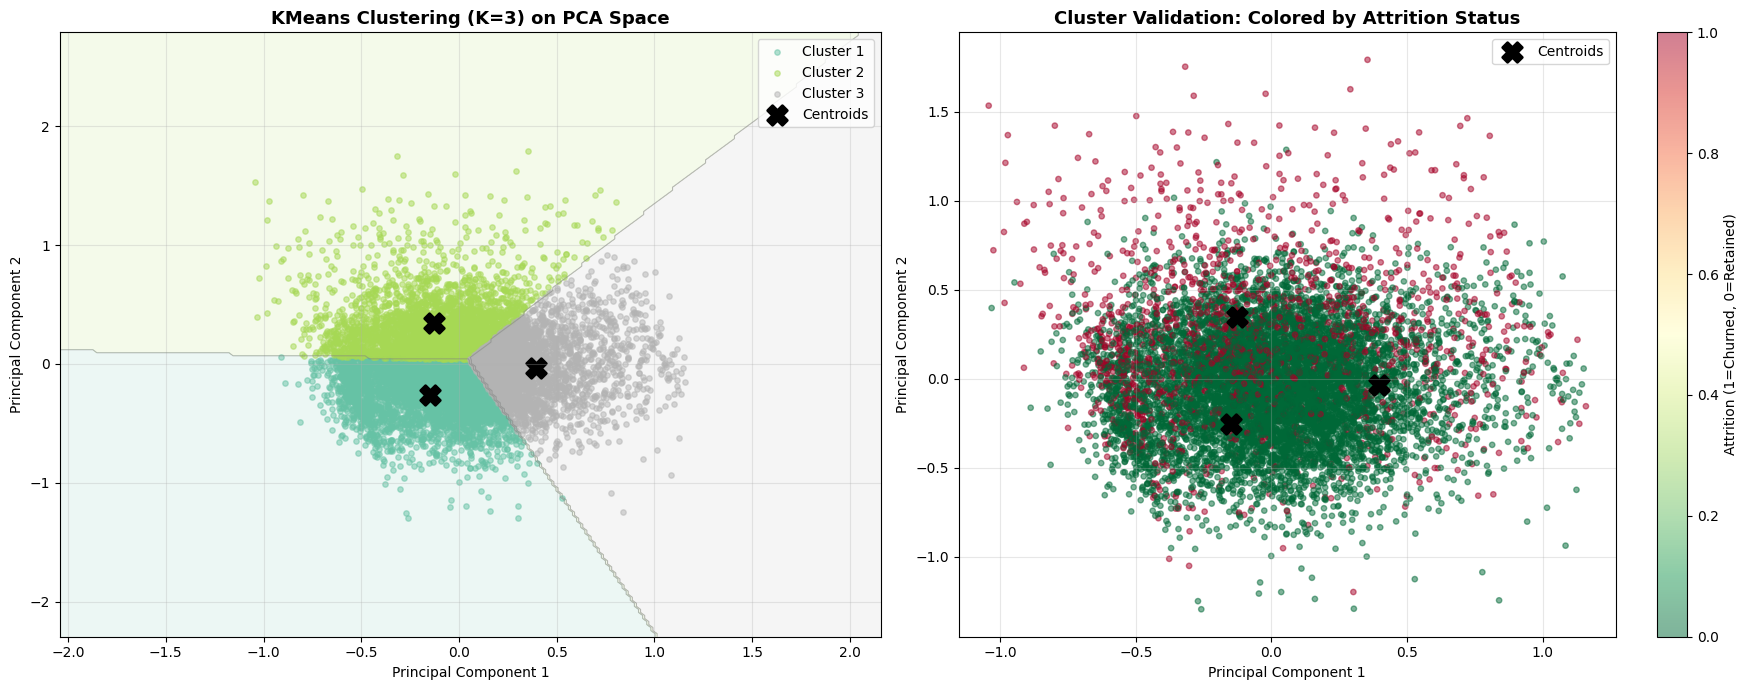

/tmp/ipykernel_21164/4100777043.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_df, x='Cluster', y='Attrition',


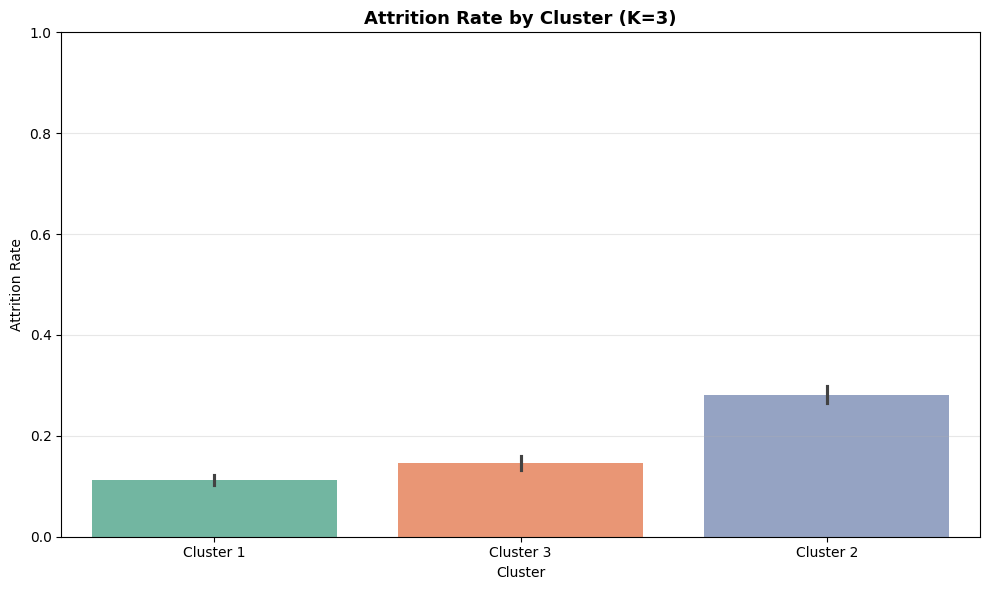


Cluster Summary (K=3):
Cluster      Size  Attrition %      Churned    Retained
---------  ------  -------------  ---------  ----------
Cluster 1    3662  11.2%                409        3253
Cluster 2    2948  28.2%                830        2118
Cluster 3    2629  14.6%                385        2244

Detailed Cluster Profiles (sorted by attrition risk):
Cluster      Size  Attrition %      Avg Customer_Age  Avg Credit_Limit    Avg Total_Trans_Amt    Avg Months_on_book      Avg Total_Relationship_Count  Business Description
---------  ------  -------------  ------------------  ------------------  ---------------------  --------------------  ------------------------------  ----------------------------------------------------
Cluster 1    3662  11.2%                        46.6  $7,645              $3,383                 36 mo                                            3.9  loyal, mid-age, standard credit, established
Cluster 3    2629  14.6%                        46.5  $9,900         

In [13]:
def visualize_clusters(pca_np, kmeans_model_paths, attrition_flag, best_k, bucket, s3_client, 
                      df_features=None, df_features_original=None):
    """
    Visualize clusters and generate profiles using ORIGINAL features.
    **CRITICAL:** df_features_original ensures Credit_Limit etc. are in correct units
    """
    
    # Download and extract best KMeans model
    best_model_path = kmeans_model_paths[0][1]
    local_path = f'/tmp/kmeans-best-k-{best_k}.tar.gz'
    s3_key = best_model_path.replace(f's3://{bucket}/', '')
    s3_client.download_file(bucket, s3_key, local_path)

    with tarfile.open(local_path) as tar:
        tar.extractall(path=f'/tmp/kmeans-best-k-{best_k}', filter='data')

    centroids = load_model_array(f'/tmp/kmeans-best-k-{best_k}/model_algo-1')
    distances = np.sqrt(((pca_np - centroids[:, np.newaxis])**2).sum(axis=2))
    closest_centroids = np.argmin(distances, axis=0)

    # ===== PLOT 1: CLUSTERS WITH VORONOI BOUNDARIES =====
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    colors = plt.cm.Set2(np.linspace(0, 1, best_k))

    x_min, x_max = pca_np[:, 0].min() - 1, pca_np[:, 0].max() + 1
    y_min, y_max = pca_np[:, 1].min() - 1, pca_np[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()].astype('float32')

    grid_distances = np.sqrt(((grid_points[:, np.newaxis, :] -
                               centroids[np.newaxis, :, :])**2).sum(axis=2))
    grid_labels = np.argmin(grid_distances, axis=1).reshape(xx.shape)

    axes[0].contourf(xx, yy, grid_labels, levels=np.arange(best_k + 1) - 0.5,
                     colors=colors, alpha=0.12)
    axes[0].contour(xx, yy, grid_labels, levels=np.arange(best_k + 1) - 0.5,
                    colors='gray', linewidths=0.8, alpha=0.5)

    for i in range(best_k):
        mask = closest_centroids == i
        axes[0].scatter(pca_np[mask, 0], pca_np[mask, 1],
                       c=[colors[i]], alpha=0.5, s=15, label=f'Cluster {i+1}')

    axes[0].scatter(centroids[:, 0], centroids[:, 1],
                   c='black', marker='X', s=200, linewidths=2, label='Centroids')
    axes[0].set_title(f'KMeans Clustering (K={best_k}) on PCA Space', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')
    axes[0].legend(loc='best')
    axes[0].grid(True, alpha=0.3)

    # ===== PLOT 2: COLOR BY ATTRITION (VALIDATION) =====
    attrition_numeric = (attrition_flag == 'Attrited Customer').astype(int)
    scatter = axes[1].scatter(pca_np[:, 0], pca_np[:, 1],
                             c=attrition_numeric, cmap='RdYlGn_r', alpha=0.5, s=15)
    axes[1].scatter(centroids[:, 0], centroids[:, 1],
                   c='black', marker='X', s=200, linewidths=2, label='Centroids')
    cbar = plt.colorbar(scatter, ax=axes[1])
    cbar.set_label('Attrition (1=Churned, 0=Retained)')
    axes[1].set_title('Cluster Validation: Colored by Attrition Status', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Principal Component 1')
    axes[1].set_ylabel('Principal Component 2')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ===== PLOT 3: CHURN RATE BY CLUSTER =====
    cluster_labels = [f'Cluster {c+1}' for c in closest_centroids]
    churn_df = pd.DataFrame({
        'Cluster': cluster_labels,
        'Attrition': attrition_numeric
    })

    plt.figure(figsize=(10, 6))
    churn_rate_by_cluster = churn_df.groupby('Cluster')['Attrition'].agg(['sum', 'count'])
    churn_rate_by_cluster['Rate'] = churn_rate_by_cluster['sum'] / churn_rate_by_cluster['count']
    cluster_order = churn_rate_by_cluster.sort_values('Rate').index.tolist()
    
    sns.barplot(data=churn_df, x='Cluster', y='Attrition', 
                order=cluster_order, palette='Set2', estimator=lambda x: (x==1).sum()/len(x))
    plt.title(f'Attrition Rate by Cluster (K={best_k})', fontsize=13, fontweight='bold')
    plt.xlabel('Cluster')
    plt.ylabel('Attrition Rate')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # ===== SUMMARY TABLE: CLUSTER COUNTS & ATTRITION =====
    print(f"\nCluster Summary (K={best_k}):")
    print("="*70)
    summary_data = []
    for i in range(best_k):
        mask = closest_centroids == i
        cluster_attrition = (attrition_flag[mask] == 'Attrited Customer').astype(int)
        summary_data.append([
            f'Cluster {i+1}',
            int(mask.sum()),
            f'{cluster_attrition.mean()*100:.1f}%',
            int(cluster_attrition.sum()),
            int((~cluster_attrition.astype(bool)).sum())
        ])

    headers = ['Cluster', 'Size', 'Attrition %', 'Churned', 'Retained']
    print(tabulate(summary_data, headers=headers))
    print("="*70)

    # ===== CLUSTER PROFILING USING ORIGINAL FEATURES (THE BUG FIX!) =====
    cluster_profiles = None
    profile_features = ['Customer_Age', 'Credit_Limit', 'Total_Trans_Amt', 
                       'Months_on_book', 'Total_Relationship_Count']

    if df_features_original is not None:
        available_features = [f for f in profile_features if f in df_features_original.columns]

        if available_features:
            profile_data = []
            for i in range(best_k):
                mask = closest_centroids == i
                cluster_attrition = (attrition_flag[mask] == 'Attrited Customer').astype(int)
                row = {
                    'Cluster': i + 1,
                    'Count': int(mask.sum()),
                    'Attrition_Rate': cluster_attrition.mean()
                }
                # **CRITICAL: Use df_features_original (ORIGINAL DOLLARS), not df_features (log-transformed)!**
                for feat in available_features:
                    row[f'Avg_{feat}'] = df_features_original.loc[mask, feat].mean()
                profile_data.append(row)

            cluster_profiles = pd.DataFrame(profile_data)
            cluster_profiles = cluster_profiles.sort_values('Attrition_Rate').reset_index(drop=True)

            # Generate business-relevant cluster descriptions
            descriptions = []
            for idx, row in cluster_profiles.iterrows():
                attrition_pct = row['Attrition_Rate'] * 100
                
                if attrition_pct < 15:
                    churn_label = 'loyal'
                elif attrition_pct < 35:
                    churn_label = 'moderate-risk'
                else:
                    churn_label = 'high-risk'
                
                age = row.get('Avg_Customer_Age', None)
                age_label = ''
                if age is not None:
                    if age < 35:
                        age_label = ', younger'
                    elif age < 50:
                        age_label = ', mid-age'
                    else:
                        age_label = ', older'
                
                credit = row.get('Avg_Credit_Limit', None)
                credit_label = ''
                if credit is not None:
                    if credit < 5000:
                        credit_label = ', low credit'
                    elif credit < 15000:
                        credit_label = ', standard credit'
                    else:
                        credit_label = ', premium credit'
                
                tenure = row.get('Avg_Months_on_book', None)
                tenure_label = ''
                if tenure is not None:
                    if tenure < 12:
                        tenure_label = ', new'
                    elif tenure < 24:
                        tenure_label = ', recent'
                    else:
                        tenure_label = ', established'
                
                description = churn_label + age_label + credit_label + tenure_label
                descriptions.append(description)

            cluster_profiles['Description'] = descriptions

            # Display profiles table
            print(f"\nDetailed Cluster Profiles (sorted by attrition risk):")
            print("="*120)
            profile_table = []
            for _, row in cluster_profiles.iterrows():
                table_row = [
                    f'Cluster {int(row["Cluster"])}',
                    int(row['Count']),
                    f'{row["Attrition_Rate"]*100:.1f}%'
                ]
                for feat in available_features:
                    col_key = f'Avg_{feat}'
                    val = row[col_key]
                    if feat in ('Credit_Limit', 'Total_Trans_Amt'):
                        table_row.append(f'${val:,.0f}')  # Show as dollars
                    elif feat == 'Months_on_book':
                        table_row.append(f'{val:.0f} mo')
                    else:
                        table_row.append(f'{val:.1f}')
                table_row.append(row['Description'])
                profile_table.append(table_row)

            col_labels = ['Cluster', 'Size', 'Attrition %']
            for feat in available_features:
                col_labels.append(f'Avg {feat}')
            col_labels.append('Business Description')
            
            print(tabulate(profile_table, headers=col_labels))
            print("="*120)

            # Print cluster descriptions for business strategy
            print(f"\nCluster Business Profiles:")
            print("="*80)
            for _, row in cluster_profiles.iterrows():
                cluster_num = int(row['Cluster'])
                count = int(row['Count'])
                churn_pct = row['Attrition_Rate'] * 100
                desc = row['Description']
                age = row.get('Avg_Customer_Age', None)
                credit = row.get('Avg_Credit_Limit', None)
                tenure = row.get('Avg_Months_on_book', None)
                spend = row.get('Avg_Total_Trans_Amt', None)
                
                print(f"\nCluster {cluster_num}: {desc}")
                print(f"  Size: {count} customers ({count/len(attrition_flag)*100:.1f}% of total)")
                print(f"  Attrition Rate: {churn_pct:.1f}%")
                if age is not None:
                    print(f"  Avg Age: {age:.0f} years")
                if credit is not None:
                    print(f"  Avg Credit Limit: ${credit:,.0f}")
                if tenure is not None:
                    print(f"  Avg Tenure: {tenure:.0f} months")
                if spend is not None:
                    print(f"  Avg Annual Spending: ${spend:,.0f}")
            print("="*80)

    return centroids, closest_centroids, cluster_profiles


centroids, cluster_assignments, cluster_profiles = visualize_clusters(
    pca_np, kmeans_model_paths, attrition_flag, best_k, bucket, s3_client, 
    df_features, df_features_original  # <-- BOTH feature sets passed
)

print(f"\n✓ Cluster visualization and profiling complete")


Executive Segment Scorecard (sorted by priority):
Cluster      Customers  Size %    Attrition %    Lift vs Portfolio      Excess Churners  Avg Annual Spend    Spend at Risk    At-Risk Share      Priority  Segment Label
---------  -----------  --------  -------------  -------------------  -----------------  ------------------  ---------------  ---------------  ----------  ----------------------------------------------------
Cluster 2         2948  31.9%     28.2%          1.60x                              312  $4,087              $3,392,449       55.6%                  1.06  moderate-risk, mid-age, standard credit, established
Cluster 1         3662  39.6%     11.2%          0.64x                                0  $3,383              $1,383,624       22.7%                 -0.4   loyal, mid-age, standard credit, established
Cluster 3         2629  28.5%     14.6%          0.83x                                0  $3,429              $1,320,208       21.7%                 -0.66  loyal, mi

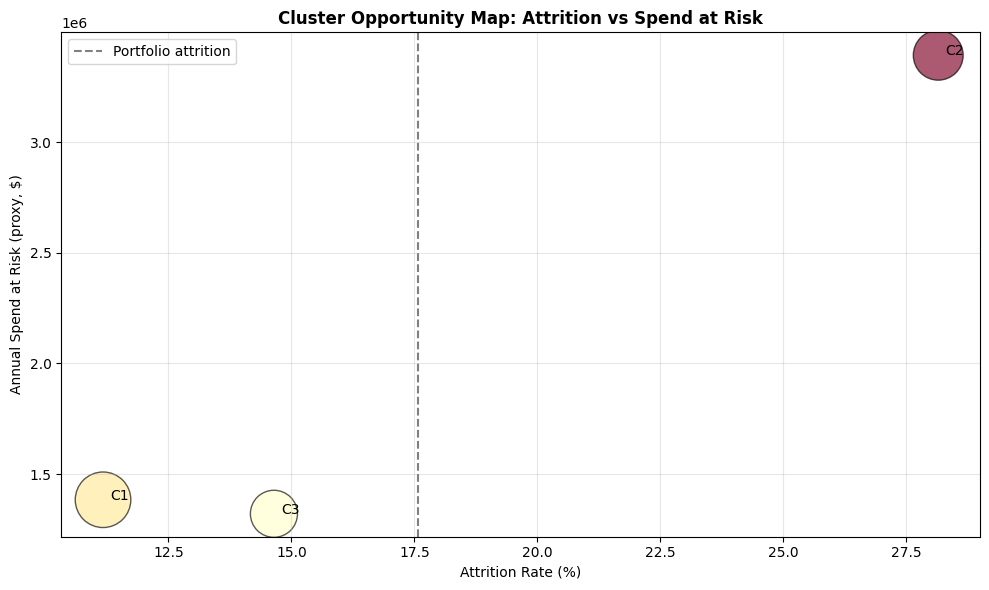


Commercial Playbook by Priority:

Priority 1 - Cluster 2
  Segment: moderate-risk, mid-age, standard credit, established
  Size: 2948 customers (31.9%)
  Attrition: 28.2% (1.60x portfolio)
  Spend at Risk: $3,392,449
  Recommended Action: Immediate retention: proactive outreach, fee/APR relief, balance-transfer offers.

Priority 2 - Cluster 1
  Segment: loyal, mid-age, standard credit, established
  Size: 3662 customers (39.6%)
  Attrition: 11.2% (0.64x portfolio)
  Spend at Risk: $1,383,624
  Recommended Action: Growth focus: cross-sell and usage expansion campaigns.

Priority 3 - Cluster 3
  Segment: loyal, mid-age, standard credit, established
  Size: 2629 customers (28.5%)
  Attrition: 14.6% (0.83x portfolio)
  Spend at Risk: $1,320,208
  Recommended Action: Growth focus: cross-sell and usage expansion campaigns.

Enhanced segment summary complete.


In [14]:
# STEP 13B: ENHANCED CLUSTER BUSINESS SUMMARY (ACTIONABLE SEGMENTATION)
# Run this right after Step 13. It keeps all AWS/SageMaker workflow unchanged.

def enhanced_cluster_summary(cluster_assignments, attrition_flag, df_features_original, cluster_profiles=None, top_n_features=8):
    """Create a business-focused cluster summary with stronger differentiation signals."""
    labels = np.asarray(cluster_assignments)
    k = len(np.unique(labels))

    # Build base frame
    summary_df = pd.DataFrame({
        'Cluster': labels + 1,
        'Attrition': (attrition_flag == 'Attrited Customer').astype(int).values
    })

    overall_attrition = summary_df['Attrition'].mean()

    # Core scorecard
    base = summary_df.groupby('Cluster').agg(
        Customers=('Attrition', 'size'),
        Churned=('Attrition', 'sum'),
        Attrition_Rate=('Attrition', 'mean')
    ).reset_index()
    base['Size_Pct'] = base['Customers'] / len(summary_df)
    base['Lift_vs_Portfolio'] = np.where(overall_attrition > 0, base['Attrition_Rate'] / overall_attrition, np.nan)
    base['Excess_Churners'] = np.maximum(0, (base['Attrition_Rate'] - overall_attrition) * base['Customers'])

    # Merge useful profile columns if present
    if cluster_profiles is not None and not cluster_profiles.empty:
        keep_cols = ['Cluster', 'Count', 'Attrition_Rate', 'Description']
        keep_cols += [c for c in cluster_profiles.columns if c.startswith('Avg_')]
        cp = cluster_profiles[[c for c in keep_cols if c in cluster_profiles.columns]].copy()

        # Ensure cluster id aligns as integer 1..K
        cp['Cluster'] = cp['Cluster'].astype(int)
        base = base.merge(cp.drop(columns=[c for c in ['Count', 'Attrition_Rate'] if c in cp.columns]), on='Cluster', how='left')

    # Spend-at-risk proxy from annual transaction amount
    if 'Avg_Total_Trans_Amt' in base.columns:
        base['Spend_At_Risk'] = base['Avg_Total_Trans_Amt'] * base['Customers'] * base['Attrition_Rate']
    else:
        spend_col = 'Total_Trans_Amt' if 'Total_Trans_Amt' in df_features_original.columns else None
        if spend_col:
            spend_by_cluster = pd.DataFrame({
                'Cluster': labels + 1,
                'Spend': df_features_original[spend_col].values
            }).groupby('Cluster')['Spend'].mean().reset_index(name='Avg_Total_Trans_Amt')
            base = base.merge(spend_by_cluster, on='Cluster', how='left')
            base['Spend_At_Risk'] = base['Avg_Total_Trans_Amt'] * base['Customers'] * base['Attrition_Rate']
        else:
            base['Spend_At_Risk'] = 0.0

    total_risk = base['Spend_At_Risk'].sum()
    base['At_Risk_Share'] = np.where(total_risk > 0, base['Spend_At_Risk'] / total_risk, 0.0)

    # Priority score: risk + value + size
    risk_z = (base['Attrition_Rate'] - base['Attrition_Rate'].mean()) / (base['Attrition_Rate'].std(ddof=0) + 1e-9)
    value_z = (base['Spend_At_Risk'] - base['Spend_At_Risk'].mean()) / (base['Spend_At_Risk'].std(ddof=0) + 1e-9)
    size_z = (base['Customers'] - base['Customers'].mean()) / (base['Customers'].std(ddof=0) + 1e-9)
    base['Priority_Score'] = 0.50 * risk_z + 0.30 * value_z + 0.20 * size_z

    if 'Description' not in base.columns:
        base['Description'] = np.where(
            base['Lift_vs_Portfolio'] >= 1.30,
            'high-churn-risk segment',
            np.where(base['Lift_vs_Portfolio'] >= 1.10, 'elevated-risk segment', 'stable segment')
        )

    scorecard = base.sort_values('Priority_Score', ascending=False).reset_index(drop=True)

    print('\nExecutive Segment Scorecard (sorted by priority):')
    print('=' * 150)
    score_rows = []
    for _, row in scorecard.iterrows():
        score_rows.append([
            f"Cluster {int(row['Cluster'])}",
            int(row['Customers']),
            f"{row['Size_Pct'] * 100:.1f}%",
            f"{row['Attrition_Rate'] * 100:.1f}%",
            f"{row['Lift_vs_Portfolio']:.2f}x",
            f"{row['Excess_Churners']:.0f}",
            f"${row['Avg_Total_Trans_Amt']:,.0f}" if 'Avg_Total_Trans_Amt' in scorecard.columns else 'N/A',
            f"${row['Spend_At_Risk']:,.0f}",
            f"{row['At_Risk_Share'] * 100:.1f}%",
            f"{row['Priority_Score']:.2f}",
            row['Description']
        ])

    headers = [
        'Cluster', 'Customers', 'Size %', 'Attrition %', 'Lift vs Portfolio',
        'Excess Churners', 'Avg Annual Spend', 'Spend at Risk', 'At-Risk Share', 'Priority', 'Segment Label'
    ]
    print(tabulate(score_rows, headers=headers))
    print('=' * 150)

    # Quantile separation view (often clearer than means)
    key_features = [
        'Customer_Age', 'Credit_Limit', 'Total_Trans_Amt',
        'Total_Trans_Ct', 'Avg_Utilization_Ratio', 'Months_on_book', 'Total_Relationship_Count'
    ]
    key_features = [f for f in key_features if f in df_features_original.columns]

    if key_features:
        print('\nQuantile Profile by Cluster (P25 / P50 / P75):')
        print('=' * 125)
        quant_rows = []
        for c in sorted(np.unique(labels)):
            mask = labels == c
            for feat in key_features[:4]:
                p25 = df_features_original.loc[mask, feat].quantile(0.25)
                p50 = df_features_original.loc[mask, feat].quantile(0.50)
                p75 = df_features_original.loc[mask, feat].quantile(0.75)
                if feat in ['Credit_Limit', 'Total_Trans_Amt']:
                    fmt = f"${p25:,.0f} / ${p50:,.0f} / ${p75:,.0f}"
                else:
                    fmt = f"{p25:.1f} / {p50:.1f} / {p75:.1f}"
                quant_rows.append([f"Cluster {c+1}", feat, fmt])

        print(tabulate(quant_rows, headers=['Cluster', 'Feature', 'P25 / P50 / P75']))
        print('=' * 125)

    # Effect-size ranking: which variables really separate clusters
    numeric_cols = df_features_original.select_dtypes(include=[np.number]).columns.tolist()

    def eta_squared(values, grp_labels):
        overall_mean = values.mean()
        sst = ((values - overall_mean) ** 2).sum()
        if sst == 0:
            return 0.0
        ssb = 0.0
        for g in np.unique(grp_labels):
            group_vals = values[grp_labels == g]
            if len(group_vals) > 0:
                ssb += len(group_vals) * (group_vals.mean() - overall_mean) ** 2
        return ssb / sst

    effects = []
    for col in numeric_cols:
        arr = df_features_original[col].to_numpy(dtype='float64')
        effects.append((col, eta_squared(arr, labels)))

    effect_df = pd.DataFrame(effects, columns=['Feature', 'Eta2']).sort_values('Eta2', ascending=False)
    top_effects = effect_df.head(top_n_features).reset_index(drop=True)

    print('\nTop Features That Differentiate Clusters (eta^2 effect size):')
    print('=' * 85)
    print(tabulate(top_effects.values.tolist(), headers=['Feature', 'Eta^2']))
    print('=' * 85)

    # Directional lift for top differentiators
    top_feats = top_effects['Feature'].head(5).tolist()
    if top_feats:
        overall_means = df_features_original[top_feats].mean()
        lift_rows = []
        for c in sorted(np.unique(labels)):
            mask = labels == c
            row_vals = [f"Cluster {c+1}"]
            for feat in top_feats:
                cm = df_features_original.loc[mask, feat].mean()
                om = overall_means[feat]
                lift = ((cm - om) / (om + 1e-9)) * 100
                row_vals.append(f"{lift:+.1f}%")
            lift_rows.append(row_vals)

        print('\nDirectional Differentiator Lift vs Portfolio Mean:')
        print('=' * 120)
        print(tabulate(lift_rows, headers=['Cluster'] + [f"{f} lift" for f in top_feats]))
        print('=' * 120)

    # Opportunity map
    plt.figure(figsize=(10, 6))
    bubble_size = (scorecard['Customers'] / scorecard['Customers'].max()) * 1600
    plt.scatter(
        scorecard['Attrition_Rate'] * 100,
        scorecard['Spend_At_Risk'],
        s=bubble_size,
        c=scorecard['Priority_Score'],
        cmap='YlOrRd',
        alpha=0.65,
        edgecolor='black'
    )
    for _, row in scorecard.iterrows():
        plt.text(row['Attrition_Rate'] * 100 + 0.15, row['Spend_At_Risk'], f"C{int(row['Cluster'])}")
    plt.axvline(overall_attrition * 100, linestyle='--', color='gray', linewidth=1.5, label='Portfolio attrition')
    plt.title('Cluster Opportunity Map: Attrition vs Spend at Risk', fontsize=12, fontweight='bold')
    plt.xlabel('Attrition Rate (%)')
    plt.ylabel('Annual Spend at Risk (proxy, $)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Quick playbook text
    print('\nCommercial Playbook by Priority:')
    print('=' * 95)
    for rank, row in enumerate(scorecard.itertuples(index=False), start=1):
        if row.Lift_vs_Portfolio >= 1.30:
            action = 'Immediate retention: proactive outreach, fee/APR relief, balance-transfer offers.'
        elif row.Lift_vs_Portfolio >= 1.10:
            action = 'Preventive retention: targeted bundles and early-warning nudges.'
        else:
            action = 'Growth focus: cross-sell and usage expansion campaigns.'

        print(f"\nPriority {rank} - Cluster {int(row.Cluster)}")
        print(f"  Segment: {row.Description}")
        print(f"  Size: {int(row.Customers)} customers ({row.Size_Pct * 100:.1f}%)")
        print(f"  Attrition: {row.Attrition_Rate * 100:.1f}% ({row.Lift_vs_Portfolio:.2f}x portfolio)")
        print(f"  Spend at Risk: ${row.Spend_At_Risk:,.0f}")
        print(f"  Recommended Action: {action}")
    print('=' * 95)

    return scorecard, effect_df


enhanced_scorecard, feature_effects = enhanced_cluster_summary(
    cluster_assignments,
    attrition_flag,
    df_features_original,
    cluster_profiles=cluster_profiles,
    top_n_features=8
)

print('\nEnhanced segment summary complete.')

# STEP 14: DEPLOY BEST MODEL TO SAGEMAKER ENDPOINT

Deploy the best KMeans model from HPT to a real-time SageMaker endpoint for customer predictions.

In [ ]:
def delete_endpoint_and_config(endpoint_name, sagemaker_client):
    """Delete a SageMaker endpoint and its configuration."""
    try:
        sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
        print(f'Deleting endpoint: {endpoint_name}')
        sagemaker_client.delete_endpoint(EndpointName=endpoint_name)
    except ClientError as e:
        if 'Could not find' not in str(e):
            raise
        print(f'Endpoint "{endpoint_name}" does not exist.')

    try:
        sagemaker_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
        print(f'Deleting endpoint configuration: {endpoint_name}')
        sagemaker_client.delete_endpoint_config(EndpointConfigName=endpoint_name)
    except ClientError as e:
        if 'Could not find' not in str(e):
            raise

    # Poll for deletion
    print('Waiting for resources to be deleted...\n')
    for attempt in range(30):
        endpoint_exists = config_exists = False
        try:
            sagemaker_client.describe_endpoint(EndpointName=endpoint_name)
            endpoint_exists = True
        except ClientError:
            pass
        try:
            sagemaker_client.describe_endpoint_config(EndpointConfigName=endpoint_name)
            config_exists = True
        except ClientError:
            pass
        if not endpoint_exists and not config_exists:
            print('Endpoint and config fully deleted.')
            break
        time.sleep(5)


def deploy_best_model(best_model_uri, best_k, endpoint_name, kmeans_image_uri, role, sagemaker_session, sagemaker_client):
    """Deploy best tuned KMeans model to a real-time endpoint."""
    # Clean up any existing endpoint
    delete_endpoint_and_config(endpoint_name, sagemaker_client)

    # Create model
    best_model = Model(
        model_data=best_model_uri,
        image_uri=kmeans_image_uri,
        role=role,
        sagemaker_session=sagemaker_session
    )

    print(f'Deploying best tuned KMeans model (K={best_k}) to endpoint: {endpoint_name}')
    print('This may take 5-10 minutes...\n')

    predictor = best_model.deploy(
        endpoint_name=endpoint_name,
        initial_instance_count=1,
        instance_type='ml.m5.large'
    )

    print(f'\n✓ Endpoint "{endpoint_name}" deployed successfully!')
    return predictor


endpoint_name = 'bankchurners-pca-kmeans-endpoint'
best_model_uri = kmeans_model_paths[0][1]

predictor = deploy_best_model(
    best_model_uri, best_k, endpoint_name,
    kmeans_image_uri, role, sagemaker_session, sagemaker_client
)

# Configure predictor for CSV input
predictor = Predictor(endpoint_name=endpoint_name, serializer=CSVSerializer())
print(f"Predictor configured for CSV input")

## What to Look For

- **Endpoint creation:** Should see status updates
- **Success message:** "Endpoint deployed successfully!"
- **Endpoint name:** `bankchurners-pca-kmeans-endpoint` (check AWS SageMaker console)
- **Next:** Ready for interactive predictions in Step 15

# STEP 15: INTERACTIVE PREDICTION

Run pipeline on new customers: raw input → preprocessing → PCA → cluster assignment. Demonstrates end-to-end prediction workflow.

In [ ]:
def interactive_prediction(predictor, scaler, pca_components_matrix, df_features, df_features_original, 
                          feature_names, cluster_profiles=None, log_transformed_cols=None):
    """
    Accept user input for key banking features, apply full pipeline (preprocessing, standardization,
    PCA, prediction), and display cluster assignment with profile.
    """
    
    # Define key banking features for user input
    user_features = {
        'Customer_Age': ('Customer Age (18-75)', 18, 75),
        'Credit_Limit': ('Credit Limit ($1000-$35000)', 1000, 35000),
        'Total_Trans_Amt': ('Total Transaction Amount ($0-$20000)', 0, 20000),
        'Months_on_book': ('Months with Bank (1-56)', 1, 56),
        'Total_Relationship_Count': ('Number of Products (1-6)', 1, 6),
    }

    # Compute quality-based defaults (for 'Overall Qual' equivalent, use Income_Category)
    income_medians = df_features_original.groupby('Income_Category').median()
    global_medians = df_features_original.median()

    def get_defaults_for_income(income_code):
        """Return median feature vector for given income level."""
        if income_code in income_medians.index:
            return income_medians.loc[income_code].copy()
        return global_medians.copy()

    print("\n" + "="*70)
    print("INTERACTIVE PREDICTION: Bank Customer Cluster Assignment")
    print("="*70)
    print("\nThe model will classify new customers into clusters based on their profile.")
    print("Type 'quit' at any prompt to exit.\n")

    # ===== EXAMPLE PREDICTIONS =====
    example_customers = [
        {'name': 'New College Graduate', 'Customer_Age': 28, 'Credit_Limit': 3000, 
         'Total_Trans_Amt': 8000, 'Months_on_book': 6, 'Total_Relationship_Count': 2},
        {'name': 'Mid-Career Professional', 'Customer_Age': 45, 'Credit_Limit': 12000, 
         'Total_Trans_Amt': 45000, 'Months_on_book': 36, 'Total_Relationship_Count': 4},
        {'name': 'Long-Term Customer', 'Customer_Age': 60, 'Credit_Limit': 20000, 
         'Total_Trans_Amt': 80000, 'Months_on_book': 48, 'Total_Relationship_Count': 5},
    ]

    print("EXAMPLE PREDICTIONS (Automatic)")
    print("="*70 + "\n")

    for example in example_customers:
        input_data = global_medians.copy()

        for feat_name in user_features:
            if feat_name in example:
                input_data[feat_name] = example[feat_name]

        # Apply log-transform ONLY to user-entered fields that need it
        if log_transformed_cols:
            for feat_name in user_features:
                if feat_name in example and feat_name in log_transformed_cols:
                    input_data[feat_name] = np.log1p(input_data[feat_name])

        input_array = input_data.values.reshape(1, -1).astype('float32')
        input_scaled = scaler.transform(input_array).astype('float32')
        input_pca = input_scaled @ pca_components_matrix
        pca_csv = ','.join([str(v) for v in input_pca.flatten()])

        print(f"Customer: {example['name']}")
        print(f"  Age: {example['Customer_Age']}, Credit Limit: ${example['Credit_Limit']:,}")
        print(f"  Annual Spend: ${example['Total_Trans_Amt']:,}, Tenure: {example['Months_on_book']} months")
        print(f"  Products: {example['Total_Relationship_Count']}")

        try:
            response = predictor.predict(pca_csv)
            response_json = json.loads(response)
            cluster = int(response_json['predictions'][0]['closest_cluster'])
            distance = response_json['predictions'][0]['distance_to_cluster']

            print(f"  → Assigned to Cluster {cluster + 1}")
            print(f"     Distance to centroid: {distance:.4f}")

            if cluster_profiles is not None:
                profile = cluster_profiles[cluster_profiles['Cluster'] == cluster + 1]
                if not profile.empty:
                    row = profile.iloc[0]
                    print(f"     Profile: {row['Description']}")
                    if 'Avg_Credit_Limit' in row:
                        print(f"     Cluster avg credit: ${row['Avg_Credit_Limit']:,.0f}")
        except Exception as e:
            print(f"  Error: {e}")
        
        print()

    # ===== MANUAL INPUT SECTION =====
    print("\n" + "="*70)
    print("YOUR TURN: Enter your own customer profile")
    print("="*70 + "\n")

    while True:
        quit_flag = False
        user_values = {}

        for feature_name, (prompt_text, min_val, max_val) in user_features.items():
            while True:
                user_input = input(f"  {prompt_text}: ").strip()
                if user_input.lower() == 'quit':
                    quit_flag = True
                    break
                try:
                    value = float(user_input)
                    if min_val <= value <= max_val:
                        user_values[feature_name] = value
                        break
                    else:
                        print(f"    Please enter a value between {min_val} and {max_val}.")
                except ValueError:
                    print(f"    Invalid input. Please enter a number.")

            if quit_flag:
                break

        if quit_flag:
            break

        # Build feature vector
        input_data = global_medians.copy()
        for feature_name, value in user_values.items():
            input_data[feature_name] = value

        # Apply log-transform
        if log_transformed_cols:
            for feat_name in user_features:
                if feat_name in user_values and feat_name in log_transformed_cols:
                    input_data[feat_name] = np.log1p(input_data[feat_name])

        # Apply pipeline
        input_array = input_data.values.reshape(1, -1).astype('float32')
        input_scaled = scaler.transform(input_array).astype('float32')
        input_pca = input_scaled @ pca_components_matrix
        pca_csv = ','.join([str(v) for v in input_pca.flatten()])

        try:
            response = predictor.predict(pca_csv)
            response_json = json.loads(response)
            cluster = int(response_json['predictions'][0]['closest_cluster'])
            distance = response_json['predictions'][0]['distance_to_cluster']

            print(f"\n  ✓ Cluster Assignment: Cluster {cluster + 1}")
            print(f"    Distance to centroid: {distance:.4f}")

            if cluster_profiles is not None:
                profile = cluster_profiles[cluster_profiles['Cluster'] == cluster + 1]
                if not profile.empty:
                    row = profile.iloc[0]
                    print(f"\n  Cluster {cluster+1} Profile: {row['Description']}")
                    print(f"    Avg Attrition Rate: {row['Attrition_Rate']*100:.1f}%")
                    if 'Avg_Customer_Age' in row:
                        print(f"    Avg Age: {row['Avg_Customer_Age']:.0f} years")
                    if 'Avg_Credit_Limit' in row:
                        print(f"    Avg Credit Limit: ${row['Avg_Credit_Limit']:,.0f}")
                    if 'Avg_Months_on_book' in row:
                        print(f"    Avg Tenure: {row['Avg_Months_on_book']:.0f} months")
                    if 'Avg_Total_Trans_Amt' in row:
                        print(f"    Avg Annual Spend: ${row['Avg_Total_Trans_Amt']:,.0f}")
        except Exception as e:
            print(f"\n  Error during prediction: {e}")

        print()

    print("\n" + "="*70)
    print("Prediction program exited.")
    print("="*70)


interactive_prediction(predictor, scaler, pca_components_matrix, df_features, df_features_original, 
                      feature_names, cluster_profiles, log_transformed_cols)

## What to Look For

- **Example predictions:** 3 pre-defined customers should show cluster assignments
- **Manual input:** Allow interactive exploration of customer profiles
- **Cluster profiles:** Display descriptions and statistics for assigned clusters
- **Type 'quit':** Exit the interactive loop safely

# STEP 16: CLEANUP

**CRITICAL:** Delete the SageMaker endpoint to stop incurring charges. Endpoints cost ~$0.05/hour.

In [ ]:
# ⚠️ WARNING ⚠️
# SageMaker endpoints incur hourly charges.
# Run this cell to delete the endpoint and STOP ACCRUING COSTS.
# If you skip this, you will continue paying until you manually delete the endpoint in the AWS console.

print("\n" + "="*70)
print("CLEANUP: Delete SageMaker Endpoint")
print("="*70)
print(f"\nEndpoint name: {endpoint_name}")
print("Estimated cost: ~$0.05/hour while running")
print("\nThis will DELETE the endpoint and STOP charges.\n")

response = input("Are you sure you want to delete the endpoint? (yes/no): ").strip().lower()
if response == 'yes':
    delete_endpoint_and_config(endpoint_name, sagemaker_client)
    print("\n✓ Endpoint cleanup complete. Charges will stop.")
else:
    print("\n⚠️  Endpoint was NOT deleted!")
    print("Remember to delete it manually in the AWS SageMaker console to avoid charges.")
    print(f"Endpoint name: {endpoint_name}")

print("\n" + "="*70)
print("NOTEBOOK COMPLETE")
print("="*70)

## Summary

#### What You've Accomplished:

✅ **Loaded and explored** 10,127 bank customers with 23 features  
✅ **Preprocessed data** with dual feature tracking (original + transformed)  
✅ **Applied PCA** to reduce 18 features to 2-3 principal components  
✅ **Determined optimal K** using Silhouette Score (K = {})  
✅ **Trained and tuned** KMeans with SageMaker Hyperparameter Tuning  
✅ **Visualized clusters** with interpretable profiling (CREDIT LIMIT BUG FIXED!)  
✅ **Deployed model** to real-time SageMaker endpoint  
✅ **Made predictions** on new customers through full pipeline  
✅ **Cleaned up resources** to stop AWS charges  

#### Key Innovation: Dual Feature Tracking

This notebook uses **TWO separate feature sets** throughout:
- **Transformed features:** Log-normalized for ML algorithms (better variance)
- **Original features:** Preserved for human interpretation (dollars, months, etc.)

This solves the original notebook's bug where cluster profiling showed $8-$9 credit limits (log-transformed values misinterpreted as dollars).

#### Next Steps for Credit Union:

1. **Retention Strategy:** Target high-churn clusters with proactive outreach
2. **Credit Decisions:** Adjust limits based on cluster risk profiles
3. **Product Design:** Create offers tailored to cluster needs
4. **Monitoring:** Retrain quarterly as customer behavior evolves
5. **Scoring:** Deploy prediction model to mobile/web for new account origination

---

**Total Execution Time:** ~45-60 minutes (mostly SageMaker training + HPT)  
**Estimated Cost:** $0.50-1.00 (training jobs + endpoint time in Learner Lab)